In [1]:
# 191805061-Salih Can Aydoğdu, 
# 201805051-Utku Enes Baki(team leader),
# 191805060-Semih Utku Polat,
# 201805044-Murat Tan

In [2]:
# configurations of PC

import socket
import platform
import re
import uuid
import psutil

# address informations
print('Address:')
print('Ip: ', socket.gethostbyname(socket.gethostname()))
print('Mac: ', ':'.join(re.findall('..', '%012x' % uuid.getnode())))

print()

# platform informations
print('Platform:')
print('Computer (Host) Name: ', platform.node())
print('OS: ' + platform.system())
print('Release: ' + platform.release())
print('Version: ' + platform.version())
print('Architecture: ' + platform.machine())
print('Processor: ' + platform.processor())

print()

# CPU informations
print('CPU:')
print('Physical Cores', psutil.cpu_count(logical = False)) # except logical cores
print('Total Cores:', psutil.cpu_count(logical = True))
print('Frequency:', psutil.cpu_freq().current / 1000, 'GHz') # megahertz to gigahertz

print()

# memory informations
memory = psutil.virtual_memory()
print('Memory:')
print('Total:', memory.total / 1024**3, 'GB') # bytes to gigabytes
print('Available:', memory.available / 1024**3, 'GB')
print('Used:', memory.used / 1024**3, 'GB')

print()

# disk informations
disk = psutil.disk_usage('/') # root directory (C:\)
print('Disk:')
print('Total:', disk.total / 1024**3, 'GB')
print('Used:', disk.used / 1024**3, 'GB')
print('Free:', disk.free / 1024**3, 'GB')

Address:
Ip:  172.29.42.223
Mac:  90:2e:16:3e:26:0f

Platform:
Computer (Host) Name:  gamma3
OS: Windows
Release: 10
Version: 10.0.19045
Architecture: AMD64
Processor: AMD64 Family 23 Model 104 Stepping 1, AuthenticAMD

CPU:
Physical Cores 6
Total Cores: 12
Frequency: 1.877 GHz

Memory:
Total: 6.822696685791016 GB
Available: 1.9150466918945312 GB
Used: 4.907649993896484 GB

Disk:
Total: 237.47075271606445 GB
Used: 212.20346069335938 GB
Free: 25.267292022705078 GB


In [3]:
# Apache Spark, büyük ölçekli veri işleme için açık kaynaklı bir birleşik analitik motorudur
# PySpark is the Python library for Apache Spark, an open-source big data processing framework
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType, LongType

from pyspark.sql.functions import split, explode, sum, lit, col, when, asc, desc, avg, mean, count, isnan

# start spark session at single local node with one thread, '-Xss3g' gives 3 GB of RAM
spark = SparkSession.builder.master('local[1]').appName('191805060_201805051_191805061_201805044').config('spark.driver.extraJavaOptions', '-Xss3g').getOrCreate()

# Enable eager evaluation of Spark SQL expressions in the REPL (Read-Eval-Print Loop)
# Yani Spark SQL komutlarinin calistirilmasini saglar
spark.conf.set('spark.sql.repl.eagerEval.enabled', True)

# path of dataset
path = 'C:/Users/gamma3/Big Data Final/netflix.csv'

# Read datasets first rows as column names (columns may nullable) and save to DataFrame(df) objects 
# CSV (Comma Separated Values)
# In Apache Spark, StructField is a class from the org.apache.spark.sql.types... 
# ...package that represents a field (column) in a structured data schema.

# Apache Spark'ta 'inferschema' seçeneği, veriyi bir dosyadan veya veri kaynağından okurken sütunların veri tiplerini...
#...otomatik olarak çıkarıp çıkarmama durumunu belirler.

users_who_rate = spark.read \
    .option('header', True) \
    .option('inferschema', True) \
    .schema(StructType([
        StructField('Movie_ID', LongType(), True),
        StructField('Name', StringType(), True),
        StructField('Year', LongType(), True),
        StructField('User_ID', LongType(), True),
        StructField('Rating', DoubleType(), True),
    ])) \
    .csv(path)

In [4]:
# is there a NaN or null value in user rating
users_who_rate.select([count(when(isnan('Rating') | col('Rating').isNull(), 'Rating'))])

count(CASE WHEN (isnan(Rating) OR (Rating IS NULL)) THEN Rating END)
0


In [5]:
# is there a NaN or null value in movie id
users_who_rate.select([count(when(isnan('Movie_ID') | col('Movie_ID').isNull(), 'Movie_ID'))])

count(CASE WHEN (isnan(Movie_ID) OR (Movie_ID IS NULL)) THEN Movie_ID END)
0


In [6]:
# is there a NaN or null value in user id
users_who_rate.select([count(when(isnan('User_ID') | col('User_ID').isNull(), 'User_ID'))])

count(CASE WHEN (isnan(User_ID) OR (User_ID IS NULL)) THEN User_ID END)
0


In [7]:
# Columns informations
users_who_rate.printSchema()

print()

users_who_rate.show(200, truncate = True)

# Count the number of unique movie IDs
unique_movie_count = users_who_rate.select("Movie_ID").distinct().count()

# users rates total row count
print('User rates total row count: ', users_who_rate.count())

print()

# Print the unique movie number result
print("Number of Unique Movie ID: ", unique_movie_count, "\n")

print()

# users rates mathematical information table
users_who_rate.select('Rating').describe()

root
 |-- Movie_ID: long (nullable = true)
 |-- Name: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- User_ID: long (nullable = true)
 |-- Rating: double (nullable = true)


+--------+--------------------+----+-------+------+
|Movie_ID|                Name|Year|User_ID|Rating|
+--------+--------------------+----+-------+------+
|    1756|Murder on the Ori...|1974|      6|   3.0|
|     175|      Reservoir Dogs|1992|      6|   5.0|
|     241|  North by Northwest|1959|      6|   3.0|
|    1765|           First Kid|1996|      6|   3.0|
|     886|                 Ray|2004|      6|   5.0|
|    1798|       Lethal Weapon|1987|      6|   3.0|
|    1799|Die Hard 2: Die H...|1990|      6|   3.0|
|     468|The Matrix: Revol...|2003|      6|   3.0|
|     985|           The Mummy|1999|      6|   4.0|
|    1803|Alien: Resurrecti...|1997|      6|   3.0|
|    3905|          The Others|2001|      6|   3.0|
|    1832|     Rosemary's Baby|1968|      6|   3.0|
|    1096|       Harlem Nights

summary,Rating
count,100000
mean,3.61908
stddev,1.0588725918219113
min,1.0
max,5.0


In [8]:
# visualization
# Seaborn, Python programlama dilinde veri görselleştirmesi için kullanılan bir veri görselleştirme kütüphanesidir.
# Seaborn'ın doğrudan Apache Spark ile entegrasyonu yoktur. Seaborn kütüphanesi, veri görselleştirmesi için genellikle... 
# ...Pandas kütüphanesiyle birlikte kullanılır.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

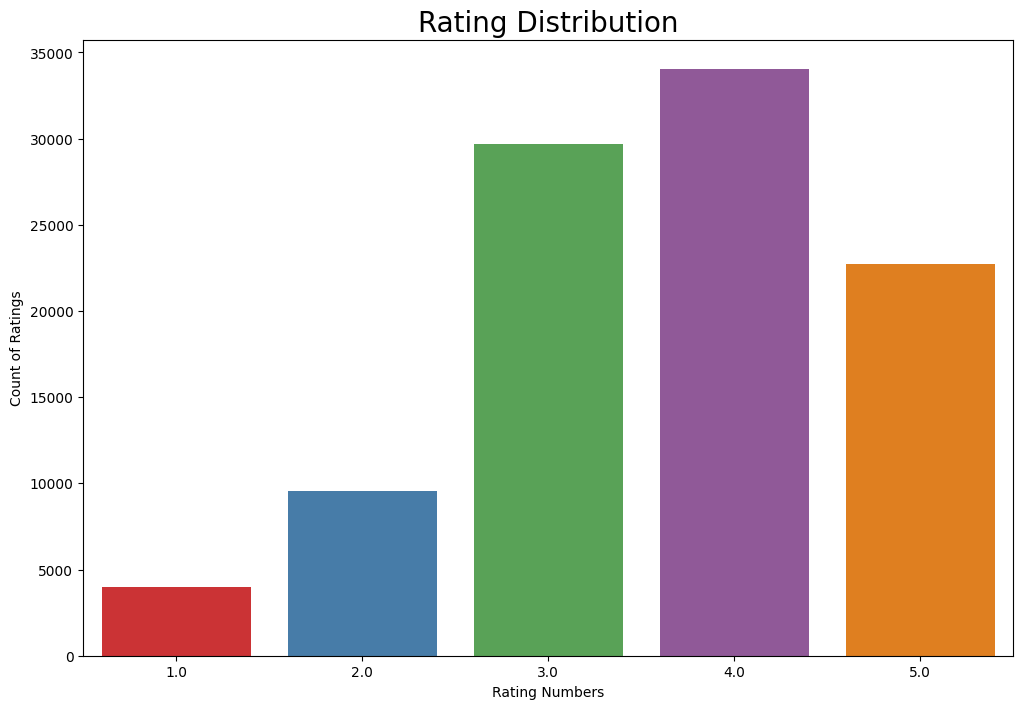

In [9]:
# Rating distribution and group by user rating and count the number of user ratings
# By using orderBy('Rating') after the groupby operation, the resulting DataFrame is sorted in... 
#...ascending order based on the 'Rating' column.

rating_distribution = users_who_rate.groupby('Rating').count().orderBy('Rating')

# Convert pyspark data frame to pandas data frame for plotting with seaborn
rating_distribution_pandas = rating_distribution.toPandas()

# rating_distribution_pandas dataframeinde count column'u olustu

# 1'den 5'e kadar olan ratinglerin kacar adet oldugunun gosterimi
plt.figure(figsize = (12, 8))
sns.barplot(x = 'Rating', y = 'count', data = rating_distribution_pandas, palette = 'Set1')
plt.title('Rating Distribution', size = 20)
plt.xlabel('Rating Numbers')
plt.ylabel('Count of Ratings')
plt.show()

In [10]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: C:\Users\gamma3\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


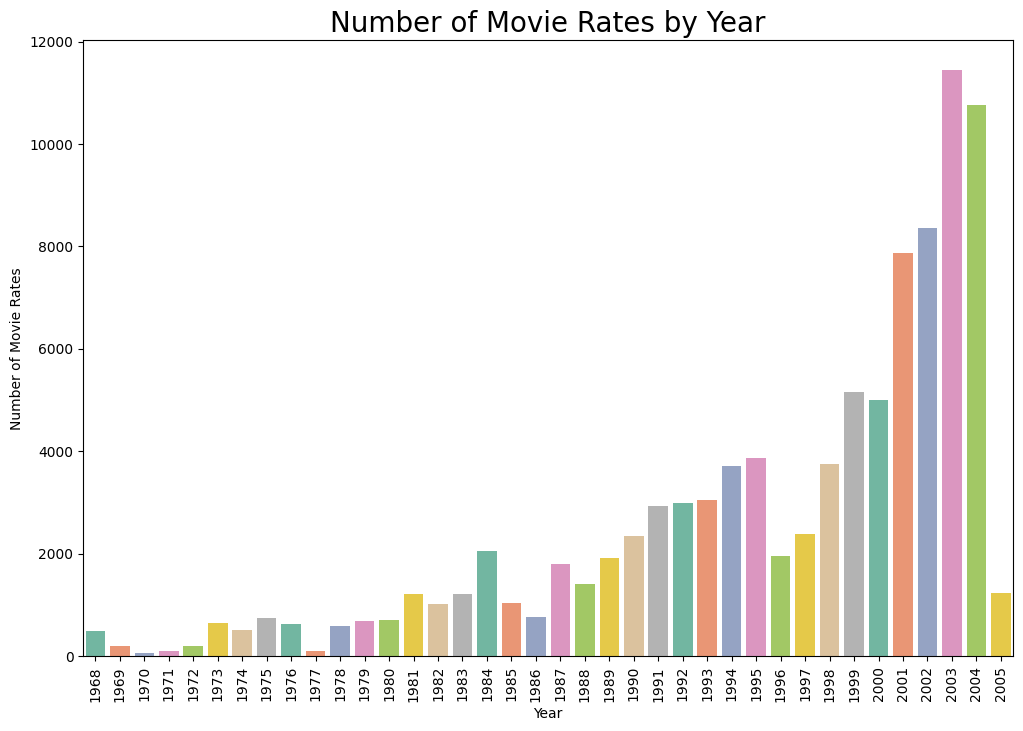

In [11]:
# Number of movies by year visualization

# Group by year and count the number of movies after 1968- we took after 1968 because before 1968 they are less information...
# ...about movies.
number_of_movies_by_year = users_who_rate.filter(users_who_rate['Year'] >= 1968).groupby('Year').count().orderBy('Year')

# convert pyspark data frame to pandas data frame for plotting with seaborn-because seaborn runs with pandas dataframe
number_of_movies_by_year_pandas = number_of_movies_by_year.toPandas()

plt.figure(figsize = (12, 8))
sns.barplot(x = 'Year', y = 'count', data = number_of_movies_by_year_pandas, palette = 'Set2')
plt.title('Number of Movie Rates by Year', size = 20)
plt.xlabel('Year')
plt.xticks(rotation = 90)
plt.ylabel('Number of Movie Rates')
plt.show()

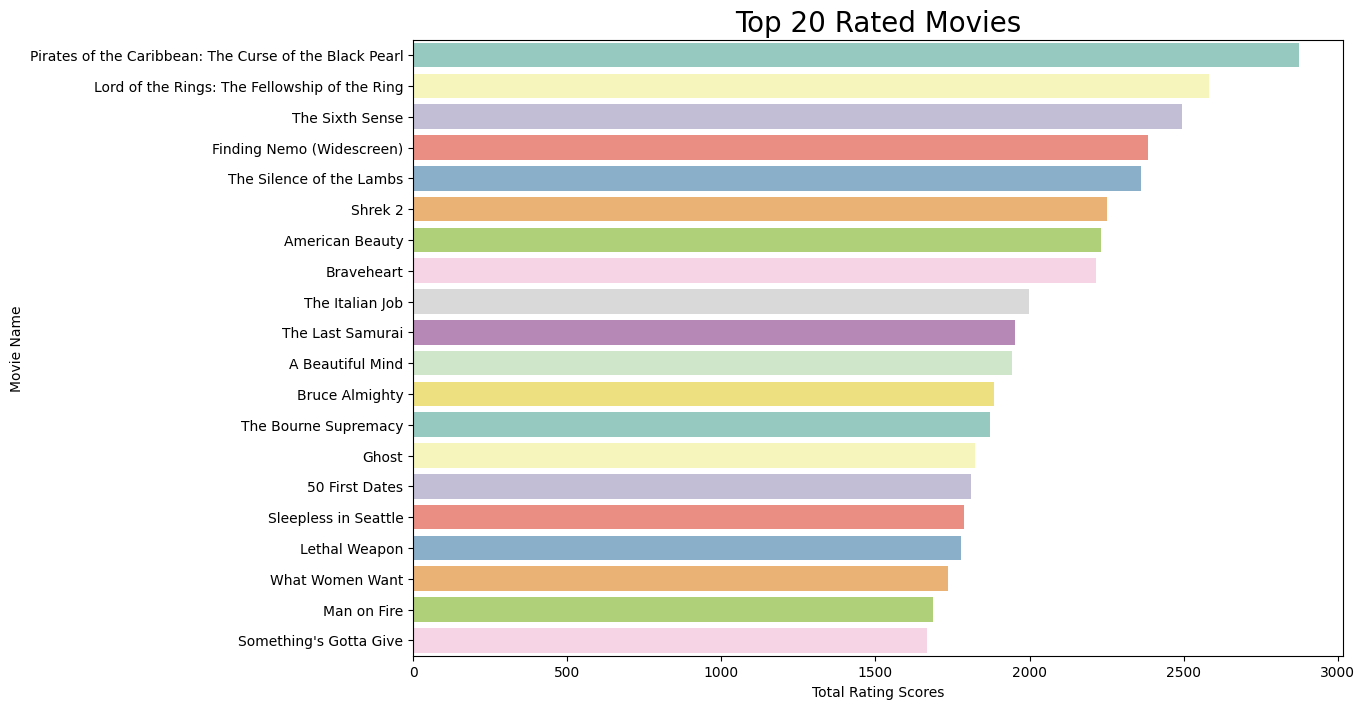

In [12]:
# Group by movie name and sum user ratings
movie_rating_distribution = users_who_rate.groupby('Name').sum('Rating')

# Convert to pandas dataframe and sort by the sum of user ratings
movie_rating_distribution_pandas = movie_rating_distribution.toPandas().sort_values(by = 'sum(Rating)', ascending = False)[:20]

plt.figure(figsize = (12, 8))
sns.barplot(x = 'sum(Rating)', y = 'Name', data = movie_rating_distribution_pandas, palette = 'Set3')
plt.title('Top 20 Rated Movies', size = 20)
plt.xlabel('Total Rating Scores')
plt.ylabel('Movie Name')
plt.show()

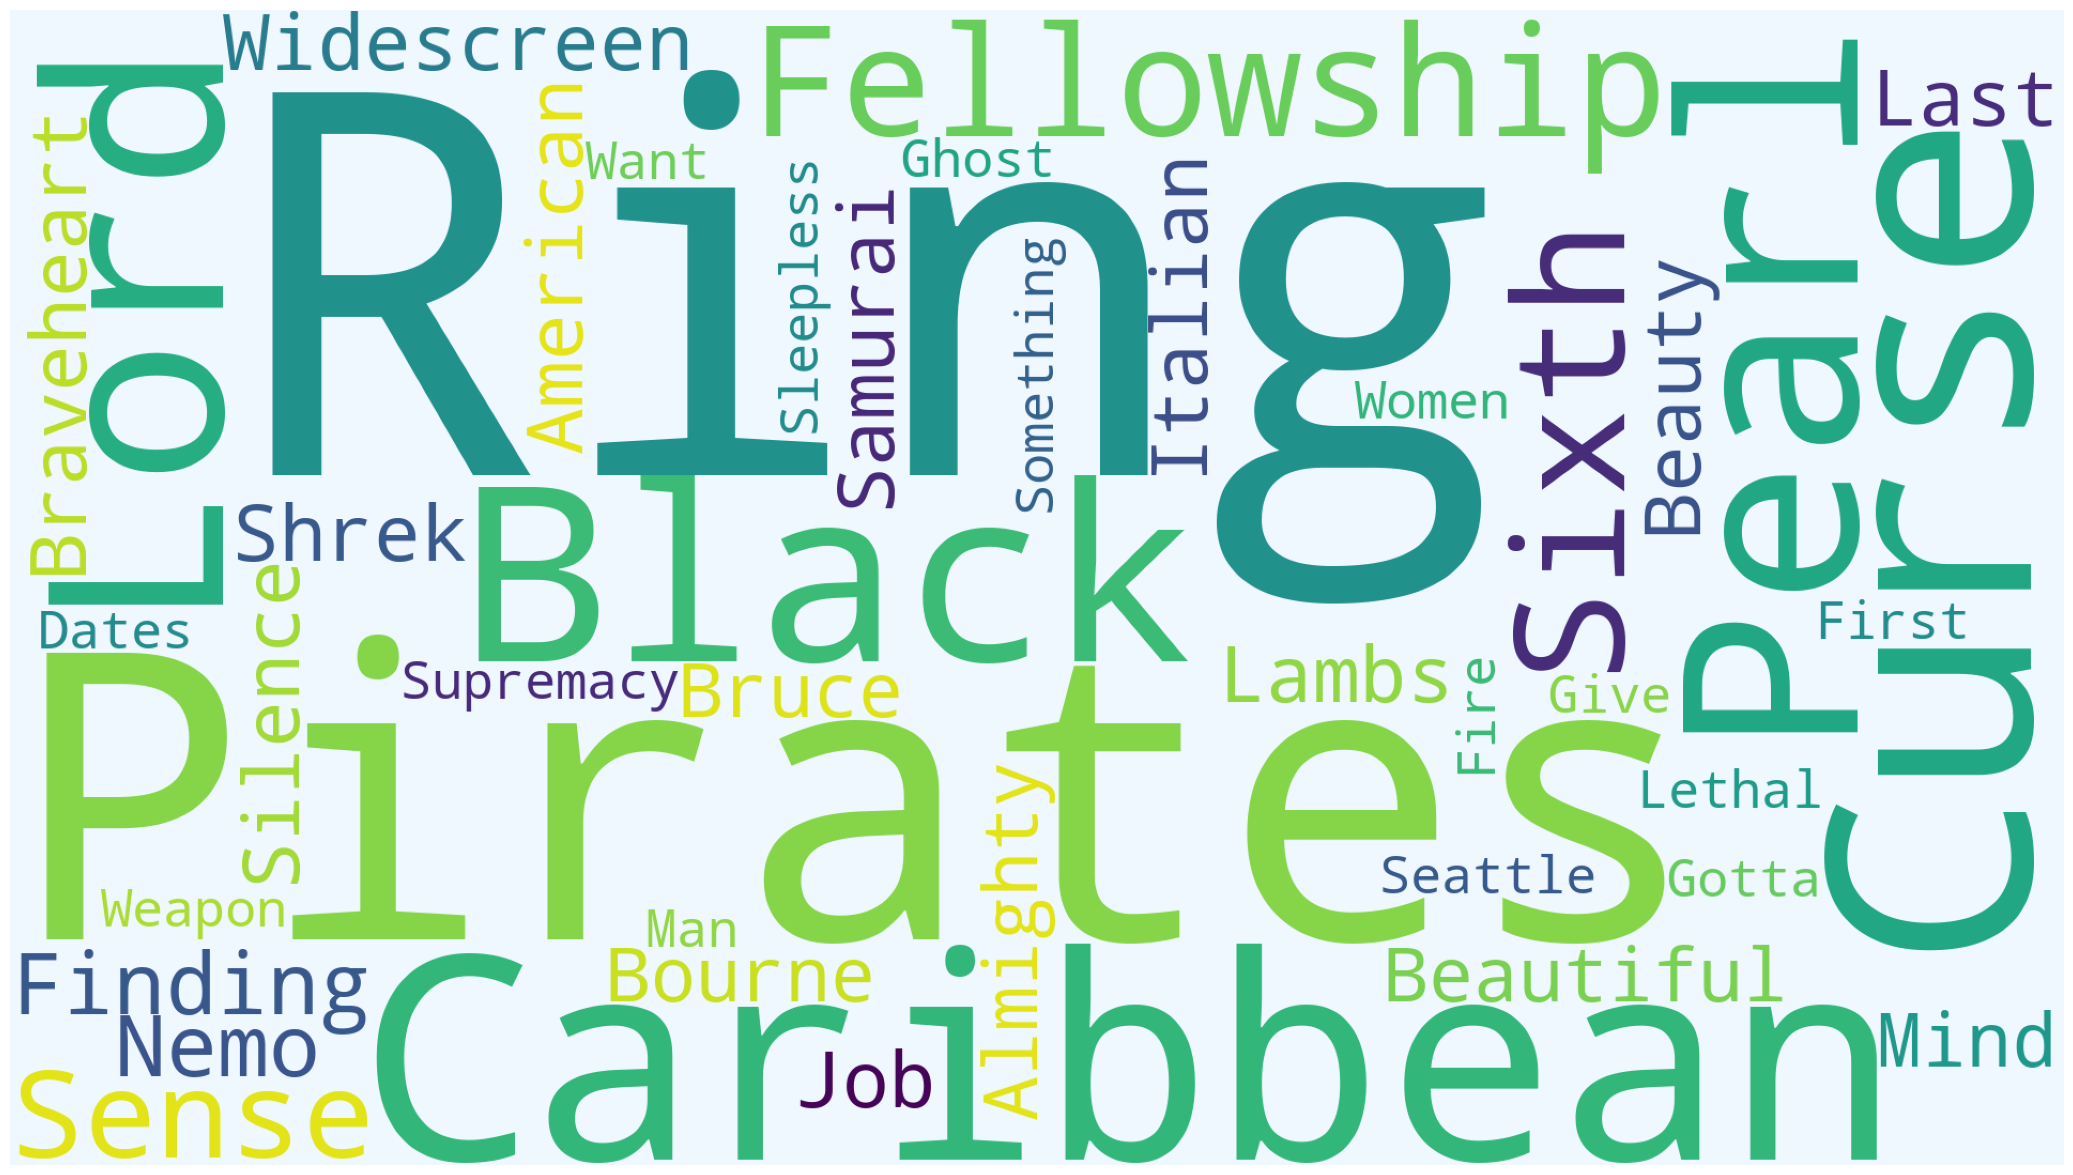

In [13]:
from wordcloud import WordCloud

# The more frequent a movie name appears in the column, the larger its representation in the word cloud and...
# ...generate() method is called with the concatenated string of movie names as input.
plt.subplots(figsize=(30, 15))
wordcloud = WordCloud(background_color='aliceblue', width=1920, height=1080).generate(" ".join(movie_rating_distribution_pandas['Name']))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [14]:
# recommendation engine

# use %70 of dataset for training, rest of them for testing
# randomly selected rows from users_who_rate_for_prediction with reference of seed
# data will split in the same way every time with same seed (use seed for consistent results)
# In our program seed gives to each of our group members, different training dataset partition and different test dataset partition
train_data, test_data = users_who_rate.randomSplit([0.7, 0.3], seed = 5061)

In [15]:
# train data total row count
print('Train data total row count: ', train_data.count())

print()

train_data = train_data.orderBy('User_ID', ascending = True)
train_data.show(200, truncate = True)

Train data total row count:  69845

+--------+--------------------+----+-------+------+
|Movie_ID|                Name|Year|User_ID|Rating|
+--------+--------------------+----+-------+------+
|     501|Three Days of the...|1975|      6|   3.0|
|    1220|         Man on Fire|2004|      6|   4.0|
|    1238|The Pope of Green...|1984|      6|   2.0|
|     173| The Devil's Brigade|1968|      6|   4.0|
|      30|Something's Gotta...|2003|      6|   3.0|
|    1971|Under Siege 2: Da...|1995|      6|   3.0|
|    2000|Four Weddings and...|1994|      6|   3.0|
|    2001|         Under Siege|1992|      6|   4.0|
|    2095|           Liar Liar|1997|      6|   4.0|
|    2112|            Identity|2003|      6|   3.0|
|    1267|      Dr. Dolittle 2|2001|      6|   3.0|
|     241|  North by Northwest|1959|      6|   3.0|
|     329|               Dogma|1999|      6|   4.0|
|     564|          Predator 2|1990|      6|   4.0|
|     580|THX 1138: Special...|1971|      6|   3.0|
|     175|      Reservoir Do

In [16]:
# test data total row count
print('Test data total row count: ', test_data.count())

print()

test_data = test_data.orderBy('User_ID', ascending = True)
test_data.show(200, truncate = True)

Test data total row count:  30155

+--------+--------------------+----+-------+------+
|Movie_ID|                Name|Year|User_ID|Rating|
+--------+--------------------+----+-------+------+
|     723|           Curly Sue|1991|      6|   3.0|
|    3689|The Amityville Ho...|2005|      6|   3.0|
|    2340|Joe Versus the Vo...|1990|      6|   3.0|
|    3860|      Bruce Almighty|2003|      6|   3.0|
|    3894| Surviving Christmas|2004|      6|   2.0|
|    1467|    Three Musketeers|1993|      6|   5.0|
|    2342|       Super Size Me|2004|      6|   3.0|
|    4149|Scooby-Doo 2: Mon...|2004|      6|   4.0|
|    4306|     The Sixth Sense|1999|      6|   4.0|
|    2372|The Bourne Supremacy|2004|      6|   5.0|
|    4393|The Mask: Special...|1994|      6|   3.0|
|    4432|     The Italian Job|2003|      6|   3.0|
|     494|Monty Python's Th...|1983|      6|   3.0|
|    2452|Lord of the Rings...|2001|      6|   5.0|
|    4472|       Love Actually|2003|      6|   3.0|
|    2456|A Fistful of Dollar

In [17]:
# ALS, Alternatif En Küçük Kareler'in kısaltmasıdır ve genellikle öneri sistemlerinde...
# ...kullanılan bir 'Collobarative Filtering' algoritmasıdır.

# 'Collaborative Filtering', bir grup kullanıcının tercihlerinden veya davranışlarından yola çıkarak... 
# ...öneriler veya tahminler yapmak için kullanılan bir tekniktir. Geçmişte benzer tercihlere sahip olan... 
# ...kullanıcıların gelecekte de benzer tercihlere sahip olacakları varsayımına dayanır - avantaji oneri performansidir

# RegressionEvaluator ise regresyon modellerinin performansını değerlendirmek için kullanılır-or. MSE,RMSE

from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS

In [18]:
# Prediction function parameters are designed for projects necessarities- “rank” 10, 50, 200, “iteration” 10, 50, 200 and “lambda” 0.01, 0.1.
# "rank": The rank parameter represents the number of latent factors in the ALS model...
# ...in collaborative filtering, the goal of "rank" is to capture the relationships or patterns in the user-item interaction matrix.

# "maxIter": The maxIter parameter determines the maximum number of iterations that ALS will perform
# "regParam": The regParam parameter controls the regularization parameter in ALS, which helps prevent overfitting.

def prediction(rank, maxIter, regParam):
    
    # --ALS--
    
    # implicitPrefs: Bu parametre 'false = explicit' ya da 'true = implicit' degeri alir calisma prensibi ise ornegin...
    # ...explicit de bir urune verdigimiz rating olurken implicit'de ise urun ile olan etkilesimimizdir-filmi izlememizin pozitif feedback kabul edilmesi
    
    # nonegative='True' oluşturulan faktör matrislerinin(kullanıcı ve ürün matrisi) negatif değer barındırmamasını sağlar, 
    #çünkü ALS uygulamalarında faktör matrislerinde öneri sistemlerinde negatif değer bulundurulmaması istikrara sebep olur
    
    # coldStartStrategy parametresi,"drop" stratejisi, yeni kullanıcıları veya yeni öğeleri sistemden çıkarırken,...
    # ..."nan" stratejisi ise tahminlerde NaN (Not a Number) değeri kullanarak yeni kullanıcılar veya öğeler için tahminler yapar.
    als = ALS(userCol = 'User_ID', itemCol = 'Movie_ID', ratingCol = 'Rating', seed = 5061, implicitPrefs = False, nonnegative = True, coldStartStrategy = 'drop', rank = rank, maxIter = maxIter, regParam = regParam)
    model = als.fit(train_data)
    predictions = model.transform(test_data)
    predictions = predictions.withColumnRenamed('prediction', 'Prediction')
    
    # RMSE (Root Mean Squared Error), bir tahmin modelinin gerçek değerlerle ne kadar uyumlu olduğunu ölçen bir hata metriğidir. 
    # RMSE, tahmin edilen değerler ile gerçek değerler arasındaki farkların karelerinin ortalamasının karekökünü hesaplar
    rmse_evaluator = RegressionEvaluator(metricName = 'rmse', labelCol = 'Rating', predictionCol = 'Prediction')
    rmse = rmse_evaluator.evaluate(predictions)
    
    # MSE (Mean Squared Error), bir regresyon modelinin tahminlerinin gerçek değerlerden ne kadar uzak olduğunu ölçen bir hata metriğidir.
    # MSE hesaplanırken, tahminler ve gerçek değerler arasındaki farklar alınarak kareleri alınır ve bu farkların ortalaması alınır.
    mse_evaluator = RegressionEvaluator(metricName = 'mse', labelCol = 'Rating', predictionCol = 'Prediction')
    mse = mse_evaluator.evaluate(predictions)

    return {'model': model, 'predictions': predictions, 'error_results': {'rank': rank, 'iteration': maxIter, 'lambda': regParam, 'RMSE': rmse, 'MSE': mse}}


In [19]:
def add_model_results(result_dict, model_name, error_results):
    """
    Verilen model adı ve hata sonuçlarına göre "result_dict" sözlüğüne sonuçları ekleyen fonksiyon.
    :param result_dict: Sonuçların ekleneceği sözlük.
    :param model_name: Modelin adı.
    :param error_results: Modelin hata sonuçları sözlüğü.
    :return: None
    """
    result_dict[model_name] = {'RMSE': error_results['RMSE'], 'MSE': error_results['MSE']}

result_dict = {}

In [20]:
# model_1_1 : dict type
# model_1_1['error_results'] : dict type
# model_1_1['predictions'] : dataframe type

model_1_1 = prediction(10, 10, 0.01)

print(model_1_1['error_results'])

print()

model_1_1['predictions'].show(200, truncate=True)

{'rank': 10, 'iteration': 10, 'lambda': 0.01, 'RMSE': 0.9978891324266991, 'MSE': 0.9957827206153103}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.1750705|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.9380772|
|     788|              Clerks|1994|  10817|   4.0| 3.9357905|
|     940|            Hercules|1997|   6336|   2.0|  2.572569|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.9951267|
|    1336|                Wolf|1994|  10817|   3.0| 3.1288185|
|    1518|              Casper|1995|  10817|   3.0| 3.0140421|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.6151667|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 4.1515675|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.9998927|
|    1975|          Hollow Man|2000|   6336|   1.0| 3.4914238|
|    2095|      

In [21]:
model_name = 'model_1_1'
error_results = model_1_1['error_results']
add_model_results(result_dict, model_name, error_results)

In [22]:
model_1_2 = prediction(10, 50, 0.01)


print(model_1_2['error_results'])

print()

model_1_2['predictions'].show(200, truncate = True)

{'rank': 10, 'iteration': 50, 'lambda': 0.01, 'RMSE': 1.0012231559769837, 'MSE': 1.0024478080645116}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.8994403|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.5409138|
|     788|              Clerks|1994|  10817|   4.0| 3.4701676|
|     940|            Hercules|1997|   6336|   2.0|  3.720387|
|    1220|         Man on Fire|2004|  10817|   4.0|  4.025529|
|    1336|                Wolf|1994|  10817|   3.0|   2.95208|
|    1518|              Casper|1995|  10817|   3.0| 2.5710557|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 4.5428543|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  4.514734|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.9613192|
|    1975|          Hollow Man|2000|   6336|   1.0| 3.1991453|
|    2095|      

In [23]:
model_name = 'model_1_2'
error_results = model_1_2['error_results']
add_model_results(result_dict, model_name, error_results)

In [24]:
model_1_3 = prediction(10, 200, 0.01)


print(model_1_3['error_results'])

print()

model_1_3['predictions'].show(200, truncate = True)

{'rank': 10, 'iteration': 200, 'lambda': 0.01, 'RMSE': 1.010064454939314, 'MSE': 1.0202302031318535}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.7756054|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.2692525|
|     788|              Clerks|1994|  10817|   4.0|  3.531917|
|     940|            Hercules|1997|   6336|   2.0| 2.9473784|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.8912802|
|    1336|                Wolf|1994|  10817|   3.0| 3.2476623|
|    1518|              Casper|1995|  10817|   3.0| 2.9608383|
|    1703|Ever After: A Cin...|1998|  10817|   3.0|  4.355635|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  4.683715|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.4728506|
|    1975|          Hollow Man|2000|   6336|   1.0|  2.886042|
|    2095|      

In [25]:
model_name = 'model_1_3'

error_results = model_1_3['error_results']
add_model_results(result_dict, model_name, error_results)

In [26]:
model_2_1 = prediction(50, 10, 0.01)


print(model_2_1['error_results'])

print()

model_2_1['predictions'].show(200, truncate = True)

{'rank': 50, 'iteration': 10, 'lambda': 0.01, 'RMSE': 1.0767434655440442, 'MSE': 1.1593764905917983}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.5421023|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.2686741|
|     788|              Clerks|1994|  10817|   4.0| 3.3857734|
|     940|            Hercules|1997|   6336|   2.0| 3.4263155|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.8201506|
|    1336|                Wolf|1994|  10817|   3.0| 3.1572902|
|    1518|              Casper|1995|  10817|   3.0|  3.766586|
|    1703|Ever After: A Cin...|1998|  10817|   3.0|  4.469896|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  3.733963|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.3171837|
|    1975|          Hollow Man|2000|   6336|   1.0| 3.9636617|
|    2095|      

In [27]:
model_name = 'model_2_1'
error_results = model_2_1['error_results']
add_model_results(result_dict, model_name, error_results)

In [28]:
model_2_2 = prediction(50, 50, 0.01)


print(model_2_2['error_results'])

print()

model_2_2['predictions'].show(200, truncate = True)

{'rank': 50, 'iteration': 50, 'lambda': 0.01, 'RMSE': 1.107306786753877, 'MSE': 1.2261283199911963}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0|  4.047602|
|     345|Star Trek: Voyage...|1998|  10817|   4.0|  3.747898|
|     788|              Clerks|1994|  10817|   4.0| 2.7076592|
|     940|            Hercules|1997|   6336|   2.0|  3.353779|
|    1220|         Man on Fire|2004|  10817|   4.0| 4.1197352|
|    1336|                Wolf|1994|  10817|   3.0|  2.959938|
|    1518|              Casper|1995|  10817|   3.0| 3.8509307|
|    1703|Ever After: A Cin...|1998|  10817|   3.0|  4.117701|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  4.247649|
|    1962|      50 First Dates|2004|   6336|   3.0|  4.859356|
|    1975|          Hollow Man|2000|   6336|   1.0|  4.343922|
|    2095|       

In [29]:
model_name = 'model_2_2'
error_results = model_2_2['error_results']
add_model_results(result_dict, model_name, error_results)

In [30]:
model_2_3 = prediction(50, 200, 0.01)


print(model_2_3['error_results'])

print()

model_2_3['predictions'].show(200, truncate = True)

{'rank': 50, 'iteration': 200, 'lambda': 0.01, 'RMSE': 1.1111065720292779, 'MSE': 1.234557814406653}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.2502952|
|     345|Star Trek: Voyage...|1998|  10817|   4.0|  3.042498|
|     788|              Clerks|1994|  10817|   4.0| 2.7775903|
|     940|            Hercules|1997|   6336|   2.0| 4.0400157|
|    1220|         Man on Fire|2004|  10817|   4.0|  3.145576|
|    1336|                Wolf|1994|  10817|   3.0| 2.8839695|
|    1518|              Casper|1995|  10817|   3.0| 3.9467247|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 4.2657228|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 4.8358684|
|    1962|      50 First Dates|2004|   6336|   3.0|  4.450628|
|    1975|          Hollow Man|2000|   6336|   1.0|  4.150452|
|    2095|      

In [31]:
model_name = 'model_2_3'
error_results = model_2_3['error_results']
add_model_results(result_dict, model_name, error_results)

In [32]:
model_3_1 = prediction(200, 10, 0.01)


print(model_3_1['error_results'])

print()

model_3_1['predictions'].show(200, truncate = True)

{'rank': 200, 'iteration': 10, 'lambda': 0.01, 'RMSE': 1.0469854381467227, 'MSE': 1.096178507691285}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.0608656|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 2.9259105|
|     788|              Clerks|1994|  10817|   4.0|  3.723724|
|     940|            Hercules|1997|   6336|   2.0| 3.8749285|
|    1220|         Man on Fire|2004|  10817|   4.0|  4.231605|
|    1336|                Wolf|1994|  10817|   3.0|  2.548692|
|    1518|              Casper|1995|  10817|   3.0| 2.8395867|
|    1703|Ever After: A Cin...|1998|  10817|   3.0|  4.637286|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  4.246461|
|    1962|      50 First Dates|2004|   6336|   3.0| 4.4761047|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.9105237|
|    2095|      

In [33]:
model_name = 'model_3_1'
error_results = model_3_1['error_results']
add_model_results(result_dict, model_name, error_results)

In [34]:
model_3_2 = prediction(200, 50, 0.01)


print(model_3_2['error_results'])

print()

model_3_2['predictions'].show(200, truncate = True)

{'rank': 200, 'iteration': 50, 'lambda': 0.01, 'RMSE': 0.9651805032454529, 'MSE': 0.9315734038451456}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.5993855|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 2.7932212|
|     788|              Clerks|1994|  10817|   4.0|  3.693413|
|     940|            Hercules|1997|   6336|   2.0| 3.2255383|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.9289868|
|    1336|                Wolf|1994|  10817|   3.0| 2.3744078|
|    1518|              Casper|1995|  10817|   3.0| 3.1745327|
|    1703|Ever After: A Cin...|1998|  10817|   3.0|  4.215871|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 4.0012336|
|    1962|      50 First Dates|2004|   6336|   3.0|  3.487062|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.9482727|
|    2095|     

In [35]:
model_name = 'model_3_2'
error_results = model_3_2['error_results']
add_model_results(result_dict, model_name, error_results)

In [36]:
model_3_3 = prediction(200, 200, 0.01)

print(model_3_3['error_results'])

print()

model_3_3['predictions'].show(200, truncate = True)

{'rank': 200, 'iteration': 200, 'lambda': 0.01, 'RMSE': 0.9279175349440477, 'MSE': 0.861030951656638}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0|  3.652263|
|     345|Star Trek: Voyage...|1998|  10817|   4.0|  3.142024|
|     788|              Clerks|1994|  10817|   4.0|  3.396087|
|     940|            Hercules|1997|   6336|   2.0|   3.43702|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.7816758|
|    1336|                Wolf|1994|  10817|   3.0| 2.5737855|
|    1518|              Casper|1995|  10817|   3.0|  3.155799|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 4.1810246|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 3.8786347|
|    1962|      50 First Dates|2004|   6336|   3.0|  3.736845|
|    1975|          Hollow Man|2000|   6336|   1.0|  2.840448|
|    2095|     

In [37]:
model_name = 'model_3_3'
error_results = model_3_3['error_results']
add_model_results(result_dict, model_name, error_results)

In [38]:
model_1_1_1 = prediction(10, 10, 0.1)

print(model_1_1_1['error_results'])

print()

model_1_1_1['predictions'].show(500, truncate = True)

{'rank': 10, 'iteration': 10, 'lambda': 0.1, 'RMSE': 0.8906350955206059, 'MSE': 0.7932308733729988}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.4094985|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.4735909|
|     788|              Clerks|1994|  10817|   4.0| 3.6526496|
|     940|            Hercules|1997|   6336|   2.0| 3.4894605|
|    1220|         Man on Fire|2004|  10817|   4.0|   3.81302|
|    1336|                Wolf|1994|  10817|   3.0| 2.8616374|
|    1518|              Casper|1995|  10817|   3.0| 3.3837101|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.5520968|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  4.033435|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.4541574|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.2672184|
|    2095|       

In [39]:
model_name = 'model_1_1_1'
error_results = model_1_1_1['error_results']
add_model_results(result_dict, model_name, error_results)

In [40]:
model_1_2_2 = prediction(10, 50, 0.1)


print(model_1_2_2['error_results'])

print()

model_1_2_2['predictions'].show(200, truncate = True)

{'rank': 10, 'iteration': 50, 'lambda': 0.1, 'RMSE': 0.8853030415872221, 'MSE': 0.7837614754435867}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.4689534|
|     345|Star Trek: Voyage...|1998|  10817|   4.0|  3.618209|
|     788|              Clerks|1994|  10817|   4.0|  3.436078|
|     940|            Hercules|1997|   6336|   2.0| 3.6645467|
|    1220|         Man on Fire|2004|  10817|   4.0|  3.818997|
|    1336|                Wolf|1994|  10817|   3.0| 2.8323963|
|    1518|              Casper|1995|  10817|   3.0| 3.3981812|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.8265214|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|   4.15046|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.2318802|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.1262038|
|    2095|       

In [41]:
model_name = 'model_1_2_2'
error_results = model_1_2_2['error_results']
add_model_results(result_dict, model_name, error_results)

In [42]:
model_1_3_3 = prediction(10, 200, 0.1)


print(model_1_3_3['error_results'])

print()

model_1_3_3['predictions'].show(200, truncate = True)

{'rank': 10, 'iteration': 200, 'lambda': 0.1, 'RMSE': 0.8853812747430586, 'MSE': 0.7839000016656434}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.3205023|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.5589838|
|     788|              Clerks|1994|  10817|   4.0|  3.547942|
|     940|            Hercules|1997|   6336|   2.0| 3.8821063|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.8100545|
|    1336|                Wolf|1994|  10817|   3.0|  2.796064|
|    1518|              Casper|1995|  10817|   3.0| 3.1971228|
|    1703|Ever After: A Cin...|1998|  10817|   3.0|  3.797484|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 4.1657834|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.0640604|
|    1975|          Hollow Man|2000|   6336|   1.0| 1.9964925|
|    2095|      

In [43]:
model_name = 'model_1_3_3'
error_results = model_1_3_3['error_results']
add_model_results(result_dict, model_name, error_results)

In [44]:
model_2_1_1 = prediction(50, 10, 0.1)


print(model_2_1_1['error_results'])

print()

model_2_1_1['predictions'].show(200, truncate = True)

{'rank': 50, 'iteration': 10, 'lambda': 0.1, 'RMSE': 0.8853435353932594, 'MSE': 0.7838331756626356}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.5244348|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.3953438|
|     788|              Clerks|1994|  10817|   4.0|  3.666222|
|     940|            Hercules|1997|   6336|   2.0| 3.2405398|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.9278378|
|    1336|                Wolf|1994|  10817|   3.0| 2.7677045|
|    1518|              Casper|1995|  10817|   3.0|  3.309532|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.7860715|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 3.9876795|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.5278263|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.2093804|
|    2095|       

In [45]:
model_name = 'model_2_1_1'
error_results = model_2_1_1['error_results']
add_model_results(result_dict, model_name, error_results)

In [46]:
model_2_2_2 = prediction(50, 50, 0.1)


print(model_2_2_2['error_results'])

print()

model_2_2_2['predictions'].show(200, truncate = True)

{'rank': 50, 'iteration': 50, 'lambda': 0.1, 'RMSE': 0.8843496665120371, 'MSE': 0.7820743326599511}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.4902682|
|     345|Star Trek: Voyage...|1998|  10817|   4.0|  3.384702|
|     788|              Clerks|1994|  10817|   4.0| 3.6096256|
|     940|            Hercules|1997|   6336|   2.0| 3.4053824|
|    1220|         Man on Fire|2004|  10817|   4.0|  4.115653|
|    1336|                Wolf|1994|  10817|   3.0| 2.6743824|
|    1518|              Casper|1995|  10817|   3.0|   3.16224|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.8336458|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 3.9272223|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.4787636|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.4005108|
|    2095|       

In [47]:
model_name = 'model_2_2_2'
error_results = model_2_2_2['error_results']
add_model_results(result_dict, model_name, error_results)

In [48]:
model_2_3_3 = prediction(50, 200, 0.1)


print(model_2_3_3['error_results'])

print()

model_2_3_3['predictions'].show(200, truncate = True)

{'rank': 50, 'iteration': 200, 'lambda': 0.1, 'RMSE': 0.8844266921676011, 'MSE': 0.7822105738185247}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.4460492|
|     345|Star Trek: Voyage...|1998|  10817|   4.0|  3.377239|
|     788|              Clerks|1994|  10817|   4.0|   3.62734|
|     940|            Hercules|1997|   6336|   2.0| 3.5372403|
|    1220|         Man on Fire|2004|  10817|   4.0| 4.0996175|
|    1336|                Wolf|1994|  10817|   3.0| 2.6623201|
|    1518|              Casper|1995|  10817|   3.0| 3.2595606|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.8220246|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  3.968407|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.5258627|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.4335454|
|    2095|      

In [49]:
model_name = 'model_2_3_3'
error_results = model_2_3_3['error_results']
add_model_results(result_dict, model_name, error_results)

In [50]:
model_3_1_1 = prediction(200, 10, 0.1)


print(model_3_1_1['error_results'])

print()

model_3_1_1['predictions'].show(200, truncate = True)

{'rank': 200, 'iteration': 10, 'lambda': 0.1, 'RMSE': 0.8848088178285242, 'MSE': 0.7828866441071105}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0|  3.320875|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.4031336|
|     788|              Clerks|1994|  10817|   4.0| 3.6341803|
|     940|            Hercules|1997|   6336|   2.0| 3.4911623|
|    1220|         Man on Fire|2004|  10817|   4.0| 3.9973922|
|    1336|                Wolf|1994|  10817|   3.0| 2.7297168|
|    1518|              Casper|1995|  10817|   3.0| 3.1402133|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.7572384|
|    1905|Pirates of the Ca...|2003|  10817|   3.0|  3.979201|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.4697564|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.4077244|
|    2095|      

In [51]:
model_name = 'model_3_1_1'
error_results = model_3_1_1['error_results']
add_model_results(result_dict, model_name, error_results)

In [52]:
model_3_2_2 = prediction(200, 50, 0.1)


print(model_3_2_2['error_results'])

print()

model_3_2_2['predictions'].show(200, truncate = True)

{'rank': 200, 'iteration': 50, 'lambda': 0.1, 'RMSE': 0.8832646119053242, 'MSE': 0.7801563746442631}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.4173427|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.3718374|
|     788|              Clerks|1994|  10817|   4.0| 3.6162744|
|     940|            Hercules|1997|   6336|   2.0| 3.5161185|
|    1220|         Man on Fire|2004|  10817|   4.0| 4.0392857|
|    1336|                Wolf|1994|  10817|   3.0| 2.7151499|
|    1518|              Casper|1995|  10817|   3.0| 3.1445215|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.8460786|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 3.9904797|
|    1962|      50 First Dates|2004|   6336|   3.0| 3.4921608|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.4400742|
|    2095|      

In [53]:
model_name = 'model_3_2_2'
error_results = model_3_2_2['error_results']
add_model_results(result_dict, model_name, error_results)

In [54]:
model_3_3_3 = prediction(200, 200, 0.1)


print(model_3_3_3['error_results'])

print()

model_3_3_3['predictions'].show(200, truncate = True)

{'rank': 200, 'iteration': 200, 'lambda': 0.1, 'RMSE': 0.8834080161077883, 'MSE': 0.7804097229234983}

+--------+--------------------+----+-------+------+----------+
|Movie_ID|                Name|Year|User_ID|Rating|Prediction|
+--------+--------------------+----+-------+------+----------+
|     290|Harold and Kumar ...|2004|  10817|   3.0| 3.4494815|
|     345|Star Trek: Voyage...|1998|  10817|   4.0| 3.3474395|
|     788|              Clerks|1994|  10817|   4.0|  3.634904|
|     940|            Hercules|1997|   6336|   2.0| 3.4817488|
|    1220|         Man on Fire|2004|  10817|   4.0|  4.044105|
|    1336|                Wolf|1994|  10817|   3.0| 2.7664437|
|    1518|              Casper|1995|  10817|   3.0| 3.1611853|
|    1703|Ever After: A Cin...|1998|  10817|   3.0| 3.8181884|
|    1905|Pirates of the Ca...|2003|  10817|   3.0| 3.9844065|
|    1962|      50 First Dates|2004|   6336|   3.0|  3.467967|
|    1975|          Hollow Man|2000|   6336|   1.0| 2.3851264|
|    2095|     

In [55]:
model_name = 'model_3_3_3'
error_results = model_3_3_3['error_results']
add_model_results(result_dict, model_name, error_results)

In [56]:
error_results = []

In [57]:
error_results.append(model_1_1['error_results'])
error_results.append(model_1_2['error_results'])
error_results.append(model_1_3['error_results'])
error_results.append(model_2_1['error_results'])
error_results.append(model_2_2['error_results'])
error_results.append(model_2_3['error_results'])
error_results.append(model_3_1['error_results'])
error_results.append(model_3_2['error_results'])
error_results.append(model_3_3['error_results'])

error_results.append(model_1_1_1['error_results'])
error_results.append(model_1_2_2['error_results'])
error_results.append(model_1_3_3['error_results'])
error_results.append(model_2_1_1['error_results'])
error_results.append(model_2_2_2['error_results'])
error_results.append(model_2_3_3['error_results'])
error_results.append(model_3_1_1['error_results'])
error_results.append(model_3_2_2['error_results'])
error_results.append(model_3_3_3['error_results'])

error_results_data_frame = spark.createDataFrame(error_results)
error_results_data_frame.show(200, truncate = True)

+------------------+------------------+---------+------+----+
|               MSE|              RMSE|iteration|lambda|rank|
+------------------+------------------+---------+------+----+
|0.9957827206153103|0.9978891324266991|       10|  0.01|  10|
|1.0024478080645116|1.0012231559769837|       50|  0.01|  10|
|1.0202302031318535| 1.010064454939314|      200|  0.01|  10|
|1.1593764905917983|1.0767434655440442|       10|  0.01|  50|
|1.2261283199911963| 1.107306786753877|       50|  0.01|  50|
| 1.234557814406653|1.1111065720292779|      200|  0.01|  50|
| 1.096178507691285|1.0469854381467227|       10|  0.01| 200|
|0.9315734038451456|0.9651805032454529|       50|  0.01| 200|
| 0.861030951656638|0.9279175349440477|      200|  0.01| 200|
|0.7932308733729988|0.8906350955206059|       10|   0.1|  10|
|0.7837614754435867|0.8853030415872221|       50|   0.1|  10|
|0.7839000016656434|0.8853812747430586|      200|   0.1|  10|
|0.7838331756626356|0.8853435353932594|       10|   0.1|  50|
|0.78207

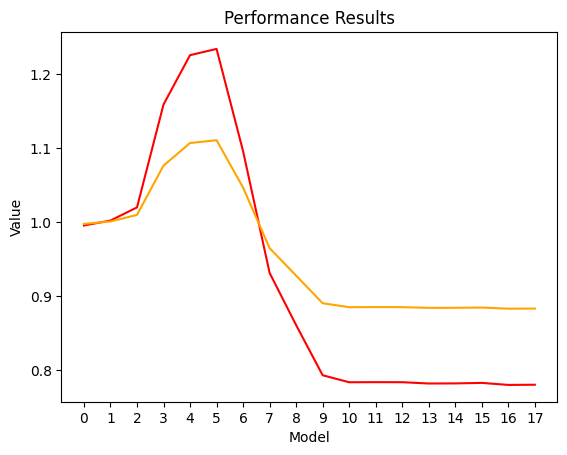

<Figure size 1200x800 with 0 Axes>

In [58]:
# convert pyspark data frame to pandas data frame - dataframe conversion in order to create plot
error_results_pandas = error_results_data_frame.toPandas()

# Plot MSE and RMSE
plt.plot(error_results_pandas.index, error_results_pandas['MSE'], linestyle='-', color = 'red', label = 'MSE')
plt.plot(error_results_pandas.index, error_results_pandas['RMSE'], linestyle='-', color = 'orange', label = 'RMSE')

# plt.plot(error_results_pandas.index, error_results_pandas['rank'], linestyle='--', color = 'purple', label = 'Rank')
# plt.plot(error_results_pandas.index, error_results_pandas['iteration'], linestyle='--', color = 'black', label = 'Iteration')
# plt.plot(error_results_pandas.index, error_results_pandas['lambda'], linestyle='--', color = 'brown', label = 'Lambda')

plt.xlabel('Model')
plt.xticks(error_results_pandas.index.astype(int))
plt.ylabel('Value')
plt.title('Performance Results')
plt.figure(figsize = (12, 8))
plt.show()

In [59]:
# Best model outputunu dinamiklestirmek icin asagidaki kodlari yazdik, ustte de asagidaki kod icin input veren fonksiyonu yazdik
model_listesi = ['model_1_1', 'model_1_2', 'model_1_3', 'model_2_1', 'model_2_2', 'model_2_3', 'model_3_1', 'model_3_2', 'model_3_3', 'model_1_1_1', 'model_1_2_2', 'model_1_3_3', 'model_2_1_1', 'model_2_2_2', 'model_2_3_3', 'model_3_1_1', 'model_3_2_2', 'model_3_3_3']

best_rmse = float('inf')
best_mse = float('inf')
best_result_index = None

# Her bir model için döngü yapildi. Enumerate fonksiyonu her bir modelin yanı sıra o modelin indeksini de sağlar. 
# Bu şekilde, hem modelin kendisine erişebilirsiniz hem de modelin kaçıncı sırada olduğunu indeks olarak alabilirsiniz.
for i, model in enumerate(model_listesi):
    result = result_dict[model]
    rmse = result['RMSE']
    mse = result['MSE']

    if rmse <= best_rmse and mse <= best_mse:
        best_rmse = rmse
        best_mse = mse
        best_result_index = i

best_model = model_listesi[best_result_index]

print('Best model based on RMSE and MSE:', result_dict[best_model])
print(f'Best model is: {best_model}', "\n")
print("The best model is selected based on having the lowest RMSE or MSE, as these indicate the model's ability to minimize prediction errors. Lower values suggest that the model's predictions are closer to the actual values, resulting in better overall performance.")

Best model based on RMSE and MSE: {'RMSE': 0.8832646119053242, 'MSE': 0.7801563746442631}
Best model is: model_3_2_2 

The best model is selected based on having the lowest RMSE or MSE, as these indicate the model's ability to minimize prediction errors. Lower values suggest that the model's predictions are closer to the actual values, resulting in better overall performance.


In [60]:
# Bizim best_model'imiz bir string type değer döndürüyor, kodumuzu dinamik hale getirebilmek için... 
# ...global() keywordunden faydalanarak bu ifadenin global'de aldıgı liste ifadesini my_dict'e atıyoruz.
if best_model in globals():
    my_dict = globals()[best_model]

In [61]:
from pyspark.sql import Row
from numpy import linalg as LA
from pyspark.sql import functions as F
import numpy as np

# In collaborative filtering and recommendation systems, the itemFactors represents the learned latent factors...
# ...for the items in the model. In collaborative filtering, latent factors are used to represent the preferences or...
# ...properties of users and items (products, movies, etc.). So we used 'itemFactors'. \\\\ itemFactors has movie_id-as id and features.
best_model_item_factors = my_dict['model'].itemFactors

# Determine movie X
movie_id = 1843
other_movies = []

# itemFactors uygulanmis halin id'si ile movie_id'nin ayni oldugu filmleri selected movie olarak atanmasi
selected_movie = best_model_item_factors.where(best_model_item_factors.id == movie_id).select('features')

# selected_movie_features secilen X filminin ALS'de hesaplanan urun-film faktorleri-RDD:Resilient Distributed Dataset
selected_movie_features = selected_movie.rdd.map(lambda x: x.features).first()

# The toLocalIterator() function returns an iterator that allows you to sequentially iterate over the elements...
# ...of the RDD on the driver program without bringing the entire RDD into memory at once.
for row in best_model_item_factors.rdd.toLocalIterator():
    # Ayni filmin similarity sini hesaplamamak icin...
    if row.id != movie_id:
        #v1 diger filmler vektoru
        v1 = np.asarray(row.features)
        #v2 secilen X filminin vektoru
        v2 = np.asarray(selected_movie_features)
        #cosine similarity formulu
        similarity_score = v1.dot(v2) / (LA.norm(v1) * LA.norm(v2))
        #diger filmlerin id'si ile similarity_score'lari, other_movies adli listede tutma
        other_movies.append([row.id, similarity_score])
R = Row('Movie_ID', 'Similarity_Score')

#other_movies liste seklinde, asagidaki kod ile onu dataframe haline getirdik - ikisi de ayni verileri iceriyor
similar_items_dataframe = spark.createDataFrame([R(column[0], float(column[1])) for column in other_movies])

# Aggregate the similarity scores using reduceByKey()
# Aggregation is a process in data analysis where data is grouped together and summarized to provide meaningful insights.
similarity_sum_rdd = similar_items_dataframe.rdd.map(lambda x: (x['Movie_ID'], x['Similarity_Score'])).reduceByKey(lambda a, b: a + b)

# Create a new DataFrame from the aggregated RDD
R = Row('Movie_ID', 'Similarity_Sum')
similarity_sum_dataframe = spark.createDataFrame([R(movie_id, similarity_sum) for movie_id, similarity_sum in similarity_sum_rdd.collect()])

In [62]:
# Select the top 10 movies by similarity sum
top_ten_movies = similarity_sum_dataframe.orderBy(similarity_sum_dataframe.Similarity_Sum.desc()).limit(10)
# Show the top 10 movies
top_ten_movies.show()

+--------+------------------+
|Movie_ID|    Similarity_Sum|
+--------+------------------+
|    1216|0.8600693299660453|
|     629|0.8595112100966648|
|    1530|0.8548991935887772|
|    3830|0.8546425389028651|
|     406|0.8537344825526306|
|    3229|0.8528497769522815|
|    1174|0.8465830071919102|
|    3826|0.8449957827719949|
|     454|0.8437066456831962|
|    3610| 0.840890976742002|
+--------+------------------+



In [63]:
# Returns list
top_ten_movie_ids = top_ten_movies.rdd.map(lambda x: x.Movie_ID).collect()

In [64]:
# Secilen X filminin ratingini veren kullanicilari filtreleyip bir dataframe'e koyduk
users_who_rated_selected_movie = my_dict['predictions'].filter(my_dict['predictions'].Movie_ID == movie_id)
user_ids_who_rated_selected_movie = users_who_rated_selected_movie.select("User_ID").rdd.flatMap(lambda x: x).collect()
# Secilen X filmine rating vermeyen userlari filtreleyip bir dataframe'e koyduk
users_without_rated_selected_movie = my_dict['predictions'].filter(~my_dict['predictions'].User_ID.isin(user_ids_who_rated_selected_movie))

In [65]:
recommended_users = []
for new_movie_id in top_ten_movie_ids:
    recommended_selected_movie = my_dict['predictions'].filter(my_dict['predictions'].Movie_ID == new_movie_id)
    sorted_ratings = recommended_selected_movie.sort(F.desc('Rating'))
    users_who_like_selected_movie = sorted_ratings.select('User_ID').limit(10)
    users_who_like_selected_movie_ids = users_who_like_selected_movie.rdd.map(lambda x: x.User_ID).collect()
    recommended_users.append({'Movie_ID': new_movie_id, 'User_ID': users_who_like_selected_movie_ids})

recommended_dataframe = spark.createDataFrame(recommended_users)
recommended_dataframe.show()

+--------+--------------------+
|Movie_ID|             User_ID|
+--------+--------------------+
|    1216|[10374, 5618, 11169]|
|     629|[7133, 1442, 1421...|
|    1530|[3998, 5727, 1143...|
|    3830|[12876, 7063, 102...|
|     406|[481, 3069, 3621,...|
|    3229| [1664, 10374, 3321]|
|    1174|[4477, 12207, 602...|
|    3826|[2976, 12876, 140...|
|     454|[2363, 12708, 140...|
|    3610|[14060, 8026, 790...|
+--------+--------------------+



In [69]:
first_row = recommended_dataframe.first()
top_users_like_count = 10

users_who_like_selected_movie = first_row["User_ID"]
remaining_user_count = top_users_like_count - len(users_who_like_selected_movie)

if remaining_user_count > 0:
    rows_to_consider = recommended_dataframe.take(remaining_user_count)[1:]
    for row in rows_to_consider:
        users_who_like_selected_movie.extend(row["User_ID"])
        remaining_user_count = top_users_like_count - len(users_who_like_selected_movie)
        if remaining_user_count <= 0:
            break

if len(users_who_like_selected_movie) > top_users_like_count:
    users_who_like_selected_movie = users_who_like_selected_movie[:top_users_like_count]

print(f"Recommended top 10 users for the movie {movie_id}: ", users_who_like_selected_movie)

Recommended top 10 users for the movie 1843:  [10374, 5618, 11169, 7133, 1442, 14210, 2455, 3101, 4477, 265]
